# Sección B — Integración de datos (incisos 4 a 8)
**Responsable:** Melanie  
**Propósito:** preparar una clave común (`Marca_Homologada`) que permita integrar CarDekho (dataset principal) con UCI Automobile (segunda fuente).

In [1]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Importación de librerías y del módulo de homologación.
# Insumo:      Ninguno
# Resultado:   Librerías cargadas y opciones de visualización configuradas.
# ===========================================================
import os                        # Crear carpetas para guardar figuras
import sys                       # Permite agregar rutas donde Python busca módulos
import pandas as pd              # Tablas (DataFrames)
import matplotlib.pyplot as plt  # Gráficas

# Se agrega la carpeta "src" a las rutas de búsqueda de Python para poder
# importar nuestro módulo propio con las funciones de la Sección B.
sys.path.append("src")
import homologacion as hm  # "hm" es un alias corto: hm.funcion(...)

# Opciones de visualización: mostrar hasta 50 columnas sin recortarlas.
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Carpeta donde se guardan las figuras del reporte (se crea si no existe).
os.makedirs("figuras", exist_ok=True)

In [2]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Carga de ambos datasets por código (no se almacenan en el repositorio).
# Insumo:      Kaggle (CarDekho) y UCI ML Repository (Automobile).
# Resultado:   DataFrames cd_raw y uci_raw.
# ===========================================================
# Se usan AMBOS datasets de la práctica:
#   - CarDekho (principal) desde Kaggle con kagglehub
#   - UCI Automobile (segunda fuente) desde UCI con ucimlrepo
# El sufijo "_raw" indica que son los datos crudos, tal como se descargaron.
# Nunca se modifican; todo el trabajo se hace sobre copias.
cd_raw = hm.cargar_cardekho()
uci_raw = hm.cargar_uci()

# shape = (número de registros, número de dimensiones)
print("CarDekho :", cd_raw.shape)
print("UCI      :", uci_raw.shape)

CarDekho : (15411, 14)
UCI      : (205, 26)


## B.4 Correspondencia entre dimensiones de ambas fuentes

In [3]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Inspección de columnas y tipos de dato de cada fuente.
# Insumo:      cd_raw, uci_raw
# Resultado:   Listado de dimensiones y tipos.
# ===========================================================
# dtypes muestra el tipo de dato de cada columna:
#   int64/float64 -> numérico, str/object -> texto.
# Sirve para saber qué columnas pueden compararse numéricamente entre fuentes.
print("CarDekho:"); print(cd_raw.dtypes, end="\n\n")
print("UCI:"); print(uci_raw.dtypes)

CarDekho:
Unnamed: 0             int64
car_name                 str
brand                    str
model                    str
vehicle_age            int64
km_driven              int64
seller_type              str
fuel_type                str
transmission_type        str
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

UCI:
price                float64
highway-mpg            int64
city-mpg               int64
peak-rpm             float64
horsepower           float64
compression-ratio    float64
stroke               float64
bore                 float64
fuel-system              str
engine-size            int64
num-of-cylinders       int64
engine-type              str
curb-weight            int64
height               float64
width                float64
length               float64
wheel-base           float64
engine-location          str
drive-wheels             str
body-style   

In [4]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Tabla de correspondencias entre dimensiones (equivalente / parcial / sin correspondencia).
# Insumo:      Análisis de columnas de ambas fuentes.
# Resultado:   DataFrame tabla_correspondencias.
# ===========================================================
# Tabla construida a partir del análisis de columnas, tipos y valores de ambas fuentes.
# Tipo de correspondencia:
#   - Equivalente: misma información, solo cambia la forma de escribirla.
#   - Parcial: información relacionada, pero con distinto detalle, unidad o categorías.
#   - Sin correspondencia: la dimensión solo existe en una de las fuentes.
tabla_correspondencias = pd.DataFrame([
    ["car_name", "make", "Parcial", "car_name = marca + modelo; make = solo fabricante"],
    ["brand", "make", "Equivalente (tras homologar)", "Ambas representan al fabricante, con diferencias de escritura"],
    ["fuel_type", "fuel-type", "Parcial", "Petrol/Diesel/CNG/LPG/Electric vs gas/diesel (Petrol ≈ gas)"],
    ["engine", "engine-size", "Parcial", "Cilindrada en cc vs tamaño de motor en pulgadas cúbicas (1 in³ = 16.387 cc)"],
    ["max_power", "horsepower", "Parcial", "bhp vs hp; escala similar pero distinto estándar de medición"],
    ["selling_price", "price", "Parcial", "INR, autos usados (India, ~2021) vs USD, precio de lista 1985"],
    ["mileage", "city-mpg / highway-mpg", "Parcial", "km/l vs millas por galón; UCI separa ciudad y carretera"],
    ["seats", "—", "Sin correspondencia", "UCI no registra asientos"],
    ["vehicle_age, km_driven, seller_type, transmission_type", "—", "Sin correspondencia", "Propias de un mercado de usados"],
    ["—", "symboling, normalized-losses, dimensiones físicas, etc.", "Sin correspondencia", "Propias de UCI (seguros y especificaciones técnicas)"],
], columns=["CarDekho", "UCI", "Tipo", "Observación"])
tabla_correspondencias

,CarDekho,UCI,Tipo,Observación
0,car_name,make,Parcial,car_name = marca + modelo; make = solo fabricante
1,brand,make,Equivalente (tras homologar),"Ambas representan al fabricante, con diferenci..."
2,fuel_type,fuel-type,Parcial,Petrol/Diesel/CNG/LPG/Electric vs gas/diesel (...
3,engine,engine-size,Parcial,Cilindrada en cc vs tamaño de motor en pulgada...
4,max_power,horsepower,Parcial,bhp vs hp; escala similar pero distinto estánd...
5,selling_price,price,Parcial,"INR, autos usados (India, ~2021) vs USD, preci..."
6,mileage,city-mpg / highway-mpg,Parcial,km/l vs millas por galón; UCI separa ciudad y ...
7,seats,—,Sin correspondencia,UCI no registra asientos
8,"vehicle_age, km_driven, seller_type, transmiss...",—,Sin correspondencia,Propias de un mercado de usados
9,—,"symboling, normalized-losses, dimensiones físi...",Sin correspondencia,Propias de UCI (seguros y especificaciones téc...


In [5]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Comparación de valores de las dimensiones pares (combustible y escalas numéricas).
# Insumo:      cd_raw, uci_raw
# Resultado:   Conteos y estadísticos comparativos.
# ===========================================================
# 1) Combustible: value_counts() cuenta cuántos registros hay de cada categoría.
#    Se observa que CarDekho tiene 5 categorías y UCI solo 2 (gas/diesel).
print("fuel_type (CarDekho):", cd_raw["fuel_type"].value_counts().to_dict())
print("fuel-type (UCI)     :", uci_raw["fuel-type"].value_counts().to_dict(), "\n")

# 2) Escalas numéricas: se comparan mínimo, mediana y máximo de cada par de columnas.
#    Si los rangos son muy distintos, hay evidencia de unidades diferentes
#    (por ejemplo, rupias vs dólares, o cc vs pulgadas cúbicas).
pares = [("engine", "engine-size"), ("max_power", "horsepower"), ("selling_price", "price")]
filas = []
for col_cd, col_uci in pares:
    filas.append([f"{col_cd} / {col_uci}",
                  cd_raw[col_cd].min(), cd_raw[col_cd].median(), cd_raw[col_cd].max(),
                  uci_raw[col_uci].min(), uci_raw[col_uci].median(), uci_raw[col_uci].max()])
comparacion = pd.DataFrame(filas, columns=["Par", "CD mín", "CD mediana", "CD máx",
                                           "UCI mín", "UCI mediana", "UCI máx"])
comparacion

fuel_type (CarDekho): {'Petrol': 7643, 'Diesel': 7419, 'CNG': 301, 'LPG': 44, 'Electric': 4}
fuel-type (UCI)     : {'gas': 185, 'diesel': 20} 



,Par,CD mín,CD mediana,CD máx,UCI mín,UCI mediana,UCI máx
0,engine / engine-size,793.0,1248.0,6592.0,61.0,120.0,326.0
1,max_power / horsepower,38.4,88.5,626.0,48.0,95.0,288.0
2,selling_price / price,40000.0,556000.0,39500000.0,5118.0,10295.0,45400.0


In [6]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Prueba: ¿car_name y make pueden usarse directamente como clave de integración?
# Insumo:      cd_raw['car_name'], uci_raw['make']
# Resultado:   Número de coincidencias exactas.
# ===========================================================
# set() obtiene los valores únicos de cada columna y "&" calcula la
# intersección: los valores que aparecen EXACTAMENTE igual en ambas fuentes.
# Si la intersección está vacía, un join con esas columnas no uniría nada.
coincide_nombre = set(cd_raw["car_name"]) & set(uci_raw["make"])
# También se prueba con "brand" (la marca ya separada) para mostrar que,
# aun al mismo nivel de detalle, las diferencias de escritura impiden el cruce.
coincide_marca  = set(cd_raw["brand"]) & set(uci_raw["make"])
print("Coincidencias exactas car_name vs make:", len(coincide_nombre))
print("Coincidencias exactas brand vs make   :", len(coincide_marca))

Coincidencias exactas car_name vs make: 0
Coincidencias exactas brand vs make   : 0


**Conclusión B.4:** `car_name` y `make` **no** pueden usarse directamente como clave: tienen distinto nivel de detalle (vehículo vs fabricante) y distinta escritura, por lo que el cruce directo produce 0 coincidencias.

## B.5 Diferencias de nivel de detalle y representación

In [7]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Ejemplos reales de incompatibilidades entre car_name (CarDekho) y make (UCI).
# Insumo:      cd_raw, uci_raw
# Resultado:   DataFrame ejemplos_incompatibilidad.
# ===========================================================
# Ejemplos tomados de los valores reales de ambas fuentes. Cada uno ilustra
# un tipo distinto de incompatibilidad: nivel de detalle, mayúsculas, marcas
# de dos palabras, inconsistencias internas, submarcas y errores ortográficos.
ejemplos_incompatibilidad = pd.DataFrame([
    ["Maruti Alto", "(no existe)", "Nombre incluye modelo; Maruti no aparece en UCI"],
    ["BMW X1", "bmw", "Nombre incluye modelo y la marca está en mayúsculas"],
    ["Mercedes-Benz C-Class", "mercedes-benz", "Nombre incluye modelo; diferencia de mayúsculas"],
    ["Land Rover Rover", "(no existe)", "Marca de dos palabras: la primera palabra ('Land') queda incompleta"],
    ["ISUZU MUX / Isuzu D-Max", "isuzu", "La misma marca se escribe distinto dentro de CarDekho"],
    ["Mercedes-AMG C", "mercedes-benz", "Submarca (AMG) del mismo fabricante"],
    ["(no existe)", "alfa-romero", "Error ortográfico en UCI (Alfa Romeo)"],
    ["(no existe)", "peugot", "Error ortográfico en UCI (Peugeot)"],
], columns=["Valor CarDekho (car_name)", "Valor UCI (make)", "Incompatibilidad"])
# Evidencia de que los ejemplos existen en los datos:
# isin() filtra las filas cuya marca está en la lista, y drop_duplicates()
# deja un solo registro por nombre para no repetir.
print(cd_raw[cd_raw["brand"].isin(["ISUZU", "Isuzu", "Land Rover", "Mercedes-AMG"])]
      .drop_duplicates("car_name")[["car_name", "brand"]])
ejemplos_incompatibilidad

               car_name         brand
240    Land Rover Rover    Land Rover
399         Isuzu D-Max         Isuzu
3553          ISUZU MUX         ISUZU
9362     Mercedes-AMG C  Mercedes-AMG
12564         Isuzu MUX         Isuzu


,Valor CarDekho (car_name),Valor UCI (make),Incompatibilidad
0,Maruti Alto,(no existe),Nombre incluye modelo; Maruti no aparece en UCI
1,BMW X1,bmw,Nombre incluye modelo y la marca está en mayús...
2,Mercedes-Benz C-Class,mercedes-benz,Nombre incluye modelo; diferencia de mayúsculas
3,Land Rover Rover,(no existe),Marca de dos palabras: la primera palabra ('La...
4,ISUZU MUX / Isuzu D-Max,isuzu,La misma marca se escribe distinto dentro de C...
5,Mercedes-AMG C,mercedes-benz,Submarca (AMG) del mismo fabricante
6,(no existe),alfa-romero,Error ortográfico en UCI (Alfa Romeo)
7,(no existe),peugot,Error ortográfico en UCI (Peugeot)


## B.6 Renombrado a español y creación de `Marca`

In [8]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Renombrado de todas las dimensiones originales a español (copias; originales intactos).
# Insumo:      cd_raw, uci_raw, diccionarios RENOMBRAR_*
# Resultado:   DataFrames cd y uci en español.
# ===========================================================
# rename() regresa un DataFrame NUEVO con las columnas renombradas según los
# diccionarios definidos en src/homologacion.py. cd_raw y uci_raw quedan intactos.
# A partir de aquí se trabaja con "cd" (CarDekho) y "uci" (UCI Automobile).
cd = cd_raw.rename(columns=hm.RENOMBRAR_CARDEKHO)
uci = uci_raw.rename(columns=hm.RENOMBRAR_UCI)
print(list(cd.columns)); print(list(uci.columns))

['Indice_Original', 'Nombre', 'Marca_Original', 'Modelo', 'Edad_Vehiculo', 'Kilómetros', 'Tipo_Vendedor', 'Combustible', 'Transmisión', 'Millaje', 'Motor', 'Potencia_Máxima', 'Asientos', 'Precio_Venta']
['Precio', 'MPG_Carretera', 'MPG_Ciudad', 'RPM_Maximas', 'Caballos_Fuerza', 'Relacion_Compresion', 'Carrera_Piston', 'Diametro_Cilindro', 'Sistema_Combustible', 'Tamano_Motor', 'Num_Cilindros', 'Tipo_Motor', 'Peso_Vacio', 'Altura', 'Ancho', 'Longitud', 'Distancia_Ejes', 'Ubicacion_Motor', 'Traccion', 'Carroceria', 'Num_Puertas', 'Aspiracion', 'Tipo_Combustible', 'Fabricante', 'Perdidas_Normalizadas', 'Nivel_Riesgo']


### Dimensiones del PDF ausentes en esta versión de CarDekho
- **`year` (Año):** no existe, pero se **deriva** de `vehicle_age`: `Año = 2021 − Edad_Vehiculo`. Supuesto: 2021 es el año de recolección/publicación del dataset en Kaggle.
- **`torque` (Torque):** no existe y **no puede derivarse** de ninguna otra dimensión (UCI tampoco lo registra). Se documenta su ausencia y **no se imputa**, para no fabricar información; los incisos 21–24 se aplican a `Millaje`, `Motor` y `Potencia_Máxima`.

In [9]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Derivación de la dimensión 'Año' a partir de 'Edad_Vehiculo' y verificación de ausencia de 'torque'.
# Insumo:      cd['Edad_Vehiculo'], hm.ANIO_RECOLECCION
# Resultado:   Nueva dimensión 'Año' en CarDekho.
# ===========================================================
# Evidencia de que las dimensiones mencionadas en el PDF no existen en esta versión.
print("¿Existe 'year' en el original?  ", "year" in cd_raw.columns)
print("¿Existe 'torque' en el original?", "torque" in cd_raw.columns)

# Año = 2021 - Edad_Vehiculo (ver supuesto en hm.ANIO_RECOLECCION).
cd["Año"] = hm.crear_anio(cd["Edad_Vehiculo"])

# Comprobación: si el cálculo es correcto, Año + Edad debe dar 2021 en TODAS
# las filas. assert detiene el notebook con error si la condición es falsa.
assert (cd["Año"] + cd["Edad_Vehiculo"] == hm.ANIO_RECOLECCION).all()
print(f"Año de referencia: {hm.ANIO_RECOLECCION} | rango de Año: {cd['Año'].min()} – {cd['Año'].max()}")
# Muestra aleatoria de 5 filas para verificar a mano.
# random_state fija la "semilla" para que siempre salgan las mismas filas.
cd[["Nombre", "Edad_Vehiculo", "Año"]].sample(5, random_state=42)

¿Existe 'year' en el original?   False
¿Existe 'torque' en el original? False
Año de referencia: 2021 | rango de Año: 1992 – 2021


,Nombre,Edad_Vehiculo,Año
3334,Hyundai i10,12,2009
10928,Maruti Baleno,4,2017
2518,Maruti Ertiga,7,2014
11322,Honda City,1,2020
9394,Maruti Alto,11,2010


In [10]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Creación de 'Marca' (primera palabra de 'Nombre') en CarDekho y a partir de 'Fabricante' en UCI.
# Insumo:      cd['Nombre'], uci['Fabricante']
# Resultado:   Nueva dimensión 'Marca' en ambos datasets.
# ===========================================================
# CarDekho: Marca = primera palabra de Nombre (regla exacta del inciso 6).
cd["Marca"] = hm.extraer_marca(cd["Nombre"])
# UCI: "make" (renombrada Fabricante) ya representa solo al fabricante.
uci["Marca"] = uci["Fabricante"]

# Validación: ¿la primera palabra coincide con la marca que ya trae el dataset?
# Las filas donde no coinciden revelan los casos que la regla no resuelve.
diferentes = cd[cd["Marca"] != cd["Marca_Original"]]
print("Registros donde Marca ≠ Marca_Original:", len(diferentes))
print(diferentes[["Nombre", "Marca_Original", "Marca"]].drop_duplicates())
cd[["Nombre", "Marca"]].head(10)

Registros donde Marca ≠ Marca_Original: 51
               Nombre Marca_Original Marca
240  Land Rover Rover     Land Rover  Land


,Nombre,Marca
0,Maruti Alto,Maruti
1,Hyundai Grand,Hyundai
2,Hyundai i20,Hyundai
3,Maruti Alto,Maruti
4,Ford Ecosport,Ford
5,Maruti Wagon R,Maruti
6,Hyundai i10,Hyundai
7,Maruti Wagon R,Maruti
8,Hyundai Venue,Hyundai
9,Maruti Swift,Maruti


## B.7 Creación de `Marca_Homologada`
Las funciones usadas están en `src/homologacion.py` (`limpiar_texto_marca`, `homologar_marca`).

Reglas aplicadas (en orden):
1. Convertir a minúsculas.
2. Eliminar espacios al inicio y final.
3. Reemplazar guiones por espacios y eliminar caracteres no alfanuméricos.
4. Aplicar el diccionario de correcciones `REGLAS_HOMOLOGACION`.

In [11]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Reglas de corrección de representación definidas para la homologación.
# Insumo:      hm.REGLAS_HOMOLOGACION
# Resultado:   Tabla de reglas.
# ===========================================================
# Se convierte el diccionario de reglas en una tabla legible:
# cada regla es (valor ya normalizado, forma común, justificación).
pd.DataFrame([(k, v[0], v[1]) for k, v in hm.REGLAS_HOMOLOGACION.items()],
             columns=["Valor normalizado", "Forma común", "Justificación"])

,Valor normalizado,Forma común,Justificación
0,land,land rover,Marca compuesta truncada por la regla 'primera...
1,alfa romero,alfa romeo,Error ortográfico en UCI: el fabricante es Alf...
2,peugot,peugeot,Error ortográfico en UCI: el fabricante es Peu...
3,mercedes amg,mercedes benz,AMG es la división deportiva de Mercedes-Benz ...


In [12]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Creación de 'Marca_Homologada' en ambos datasets sin modificar las dimensiones originales.
# Insumo:      cd['Marca'], uci['Marca']
# Resultado:   Nueva dimensión 'Marca_Homologada'.
# ===========================================================
# Se aplica la MISMA función a ambas fuentes: así ambas quedan escritas con
# las mismas reglas y pueden compararse. Se crea una columna nueva; "Marca"
# y "Nombre" no cambian.
cd["Marca_Homologada"] = hm.homologar_marca(cd["Marca"])
uci["Marca_Homologada"] = hm.homologar_marca(uci["Marca"])

# nunique() cuenta valores distintos. Si baja, se unificaron variantes de la
# misma marca (ej. "ISUZU" e "Isuzu" -> "isuzu").
print("Clases de Marca en CarDekho: antes", cd["Marca"].nunique(), "-> después", cd["Marca_Homologada"].nunique())
print("Clases de Marca en UCI     : antes", uci["Marca"].nunique(), "-> después", uci["Marca_Homologada"].nunique())
# Comprobación de que la dimensión original sigue idéntica a la descargada.
assert cd["Nombre"].equals(cd_raw["car_name"]), "No se debe modificar la dimensión original"
cd[["Marca", "Marca_Homologada"]].drop_duplicates().sort_values("Marca_Homologada")

Clases de Marca en CarDekho: antes 32 -> después 30
Clases de Marca en UCI     : antes 22 -> después 22


,Marca,Marca_Homologada
147,Audi,audi
1172,Bentley,bentley
111,BMW,bmw
47,Datsun,datsun
3799,Ferrari,ferrari
13450,Force,force
4,Ford,ford
23,Honda,honda
1,Hyundai,hyundai
3553,ISUZU,isuzu


Marcas en común ANTES   : 0 []
Marcas en común DESPUÉS : 12 ['audi', 'bmw', 'honda', 'isuzu', 'jaguar', 'mercedes benz', 'nissan', 'porsche', 'renault', 'toyota', 'volkswagen', 'volvo']
Registros de CarDekho cuya marca existe en UCI: 29.4%


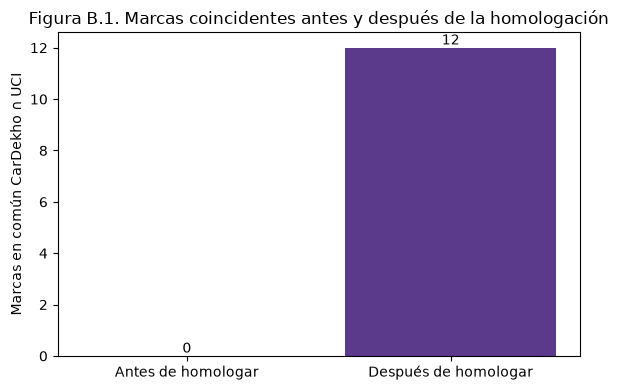

In [13]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Comparación del número de marcas en común antes y después de homologar (con gráfica).
# Insumo:      cd, uci
# Resultado:   Métrica de coincidencias y Figura B.1.
# ===========================================================
# Intersección de marcas únicas sin homologar ("Marca") y homologadas.
antes = set(cd["Marca"]) & set(uci["Marca"])
despues = set(cd["Marca_Homologada"]) & set(uci["Marca_Homologada"])
print("Marcas en común ANTES   :", len(antes), sorted(antes))
print("Marcas en común DESPUÉS :", len(despues), sorted(despues))

# Porcentaje de REGISTROS (no de marcas) de CarDekho que tendrán pareja en UCI.
# isin() da True/False por fila; mean() de booleanos = proporción de True.
filas_cd = cd["Marca_Homologada"].isin(despues).mean() * 100
print(f"Registros de CarDekho cuya marca existe en UCI: {filas_cd:.1f}%")

# Figura B.1: gráfica de barras con el número de marcas en común.
fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(["Antes de homologar", "Después de homologar"], [len(antes), len(despues)],
                color=["#b0b0b0", "#5b3a8c"])
ax.bar_label(barras)                       # Escribe el valor encima de cada barra
ax.set_ylabel("Marcas en común CarDekho ∩ UCI")
ax.set_title("Figura B.1. Marcas coincidentes antes y después de la homologación")
plt.tight_layout()                         # Ajusta márgenes para que no se corten textos
# Se guarda la imagen para insertarla en el reporte (dpi = resolución).
plt.savefig("figuras/figura_B1_coincidencias.png", dpi=150)
plt.show()

## B.8 `tabla_homologacion_marcas`

In [14]:
# ===========================================================
# Autor:       Melanie
# Fecha:       03 octubre 2026
# Descripción: Construcción reproducible de la tabla de homologación de marcas y exportación a CSV.
# Insumo:      cd, uci
# Resultado:   tabla_homologacion_marcas (DataFrame y CSV).
# ===========================================================
# La tabla se genera 100% por código (outer join de marcas únicas), sin
# editar registros a mano, para que sea reproducible (requisito del inciso 8).
tabla_homologacion_marcas = hm.construir_tabla_homologacion(cd, uci)

# Se exporta para que la use la integración (inciso 9). "utf-8-sig" hace que
# Excel muestre bien los acentos al abrir el CSV.
os.makedirs("data/processed", exist_ok=True)
tabla_homologacion_marcas.to_csv("data/processed/tabla_homologacion_marcas.csv", index=False, encoding="utf-8-sig")

# Se cuentan fabricantes homologados únicos (Isuzu/ISUZU cuentan como uno solo)
n_match = tabla_homologacion_marcas.loc[tabla_homologacion_marcas["Correspondencia"], "Marca_Homologada"].nunique()
print(f"Fabricantes CarDekho con correspondencia en UCI: {n_match} de {cd['Marca_Homologada'].nunique()} "
      f"({n_match / cd['Marca_Homologada'].nunique() * 100:.1f}%)")
tabla_homologacion_marcas

Fabricantes CarDekho con correspondencia en UCI: 12 de 30 (40.0%)


,Marca_CarDekho,Marca_UCI,Marca_Homologada,Correspondencia,Justificación
0,Audi,audi,audi,True,CarDekho: Normalización: minúsculas | UCI: Sin...
1,BMW,bmw,bmw,True,CarDekho: Normalización: minúsculas | UCI: Sin...
2,Honda,honda,honda,True,CarDekho: Normalización: minúsculas | UCI: Sin...
3,Isuzu,isuzu,isuzu,True,CarDekho: Normalización: minúsculas | UCI: Sin...
4,ISUZU,isuzu,isuzu,True,CarDekho: Normalización: minúsculas | UCI: Sin...
5,Jaguar,jaguar,jaguar,True,CarDekho: Normalización: minúsculas | UCI: Sin...
6,Mercedes-Benz,mercedes-benz,mercedes benz,True,"CarDekho: Normalización: minúsculas, guion ree..."
7,Mercedes-AMG,mercedes-benz,mercedes benz,True,CarDekho: AMG es la división deportiva de Merc...
8,Nissan,nissan,nissan,True,CarDekho: Normalización: minúsculas | UCI: Sin...
9,Porsche,porsche,porsche,True,CarDekho: Normalización: minúsculas | UCI: Sin...
